## MATH 152 Lab 9

Put team members' names and section number here.

In [29]:
import sympy as sp
from sympy import *
from sympy.plotting import (plot,plot_parametric)
import matplotlib.pyplot as plt



Instructions: Complete the lab assignment in your assigned groups. Unless stated otherwise, your answers should be obtained using Python code.

Do not modify the cell above, as it contains all the packages you will need. It is highly recommended to not use any additional packages.

### Question 1

#### 1a

In [30]:
# Enter your code here
fib = [1, 1]
for i in range(2,16):
    fib.append(fib[i-1] + fib[i-2])

print(fib)
# print 13th and 16th Fibonacci numbers
print(f"13th Fibonacci number: {fib[12]}")
print(f"16th Fibonacci number: {fib[15]}")


[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987]
13th Fibonacci number: 233
16th Fibonacci number: 987


#### 1b

In [31]:
# Enter your code here
x = sp.symbols('x')
f = x / (1 - x - x**2)
coeffs = []
for n in range(1,17):
    dn = sp.diff(f,x,n)
    cn = dn.subs(x,0) / sp.factorial(n)
    coeffs.append(cn)

print(coeffs)
print(f"13th Fibonacci number from coefficients: {coeffs[12]}")
print(f"16th Fibonacci number from coefficients: {coeffs[15]}")


[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987]
13th Fibonacci number from coefficients: 233
16th Fibonacci number from coefficients: 987


#### 1c

In [32]:
# Enter your code here
c1, c2, c3, c4, c5, c6 = sp.symbols('c_1 c_2 c_3 c_4 c_5 c_6')

f = x / (1 - x - x**2)
partial_sum = c1*x + c2*x**2 + c3*x**3 + c4*x**4 + c5*x**5 + c6*x**6
product = sp.expand((1 - x - x**2) * partial_sum)
product_collected = sp.collect(product, x)
print(product_collected)
print( """
Since f(x) = x/(1-x-x^2), multiplying both sides by (1-x-x^2) gives:
x = (1 - x - x^2) * Σ c_n x^n
""")


c_1*x - c_6*x**8 + x**7*(-c_5 - c_6) + x**6*(-c_4 - c_5 + c_6) + x**5*(-c_3 - c_4 + c_5) + x**4*(-c_2 - c_3 + c_4) + x**3*(-c_1 - c_2 + c_3) + x**2*(-c_1 + c_2)

Since f(x) = x/(1-x-x^2), multiplying both sides by (1-x-x^2) gives:
x = (1 - x - x^2) * Σ c_n x^n



### Question 2

#### 2a

In [33]:
# Enter your code here
x = sp.symbols('x')

# 1/(1+x^2) = 1/(1-(-x^2)) = sum_{n=0}^{inf} (-x^2)^n = sum (-1)^n * x^(2n)
# Integrate term by term: arctan(x) = sum_{n=0}^{inf} (-1)^n * x^(2n+1) / (2n+1)

print("Part a) First 10 nonzero terms of the power series for arctan(x):\n")

arctan_terms = []
arctan_series = 0
for n in range(10):
    term = ((-1)**n * x**(2*n + 1)) / (2*n + 1)
    arctan_terms.append(term)
    arctan_series += term
    print(f"  n={n}: {term}")
print("Arctan series expansion:", arctan_series)
print("""
General formula:
  arctan(x) = sum_{n=0}^{inf} (-1)^n * x^(2n+1) / (2n+1)
             = x - x^3/3 + x^5/5 - x^7/7 + ...
""")

Part a) First 10 nonzero terms of the power series for arctan(x):

  n=0: x
  n=1: -x**3/3
  n=2: x**5/5
  n=3: -x**7/7
  n=4: x**9/9
  n=5: -x**11/11
  n=6: x**13/13
  n=7: -x**15/15
  n=8: x**17/17
  n=9: -x**19/19
Arctan series expansion: -x**19/19 + x**17/17 - x**15/15 + x**13/13 - x**11/11 + x**9/9 - x**7/7 + x**5/5 - x**3/3 + x

General formula:
  arctan(x) = sum_{n=0}^{inf} (-1)^n * x^(2n+1) / (2n+1)
             = x - x^3/3 + x^5/5 - x^7/7 + ...



#### 2b

In [34]:
# Enter your code here
target = 5e-6
N_b = 0
while 4 / (2*N_b + 1) >= target:
    N_b += 1
print(f"Part b) Minimum N such that |R_N(1)| <= 5e-6: N = {N_b}")

partial_sums_b = []
total = 0
for n in range(N_b):
    total += 4 * ((-1)**n) / (2*n + 1)
    partial_sums_b.append(float(total))
print(f"Approximation with {N_b} terms: {partial_sums_b[N_b-1]:.7f}")



Part b) Minimum N such that |R_N(1)| <= 5e-6: N = 400000
Approximation with 400000 terms: 3.1415902


#### 2c

In [35]:
# Enter your code here

val = 1 / 3**.5
N_c = 0
while 6 * (val**(2*N_c + 1)) / (2*N_c + 1) >= target:
    N_c += 1
print(f"Part c) Minimum N such that |R_N(1/sqrt(3))| <= 5e-6: N = {N_c}")
partial_sums_c = []
total = 0
for n in range(50):
    total += 6 * ((-1)**n) * (val**(2*n + 1)) / (2*n + 1)
    partial_sums_c.append(float(total))
print(f"Approximation with {N_c} terms: {partial_sums_c[N_c-1]:.7f}")

Part c) Minimum N such that |R_N(1/sqrt(3))| <= 5e-6: N = 10
Approximation with 10 terms: 3.1415905


#### 2d

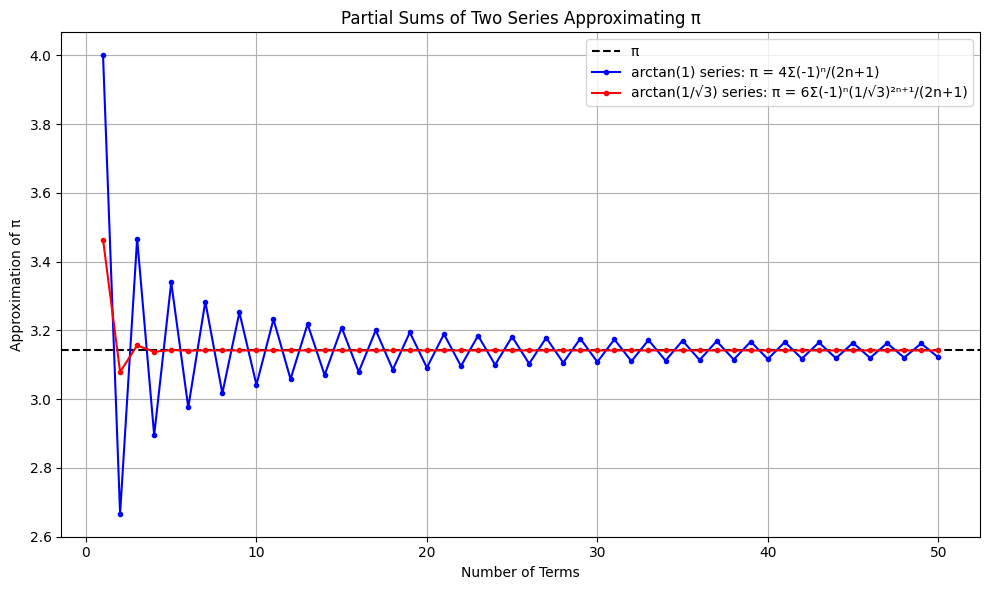


Arctan(1/sqrt3) converges much faster because the second series has a 1/sqrt(3)^(2n+1) term which decreases much more rapidly than the 1 in the first series. 
      This leads to a much smaller remainder term R_N for the same N, allowing us to achieve the desired accuracy with fewer terms.







In [36]:
# Enter your code here
pi_val = float(pi)

plt.figure(figsize=(10, 6))
plt.axhline(y=pi_val, color='black', linewidth=1.5, linestyle='--', label='π')
plt.plot(range(1, 51), partial_sums_b[:50], 'b.-', label='arctan(1) series: π = 4Σ(-1)ⁿ/(2n+1)')
plt.plot(range(1, 51), partial_sums_c[:50], 'r.-', label='arctan(1/√3) series: π = 6Σ(-1)ⁿ(1/√3)²ⁿ⁺¹/(2n+1)')
plt.xlabel('Number of Terms')
plt.ylabel('Approximation of π')
plt.title('Partial Sums of Two Series Approximating π')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pi_series.png', dpi=150)
plt.show()

print("""
Arctan(1/sqrt3) converges much faster because the second series has a 1/sqrt(3)^(2n+1) term which decreases much more rapidly than the 1 in the first series. 
      This leads to a much smaller remainder term R_N for the same N, allowing us to achieve the desired accuracy with fewer terms.
      
      
      
      
""")



### Question 3

#### 3a

In [37]:
x = sp.symbols('x')
pi = sp.pi

f = 4*sp.floor(x) - 2*sp.floor(2*x) + 1

def S(n):
    return (4/pi) * sum(
        (1/(2*k - 1)) * sp.sin(2*pi*(2*k - 1)*x)
        for k in range(1, n + 1)
    )

S1 = sp.simplify(S(1))
S2 = sp.simplify(S(2))
S3 = sp.simplify(S(3))
S4 = sp.simplify(S(4))
S5 = sp.simplify(S(5))
print("S_1(x) =", S1)
print("S_2(x) =", S2)
print("S_3(x) =", S3)
print("S_4(x) =", S4)
print("S_5(x) =", S5)


S_1(x) = 4.0*sin(2*pi*x)/pi
S_2(x) = (4.0*sin(2*pi*x) + 1.33333333333333*sin(6*pi*x))/pi
S_3(x) = (4.0*sin(2*pi*x) + 1.33333333333333*sin(6*pi*x) + 0.8*sin(10*pi*x))/pi
S_4(x) = (4.0*sin(2*pi*x) + 1.33333333333333*sin(6*pi*x) + 0.8*sin(10*pi*x) + 0.571428571428571*sin(14*pi*x))/pi
S_5(x) = (4.0*sin(2*pi*x) + 1.33333333333333*sin(6*pi*x) + 0.8*sin(10*pi*x) + 0.571428571428571*sin(14*pi*x) + 0.444444444444444*sin(18*pi*x))/pi


#### 3b

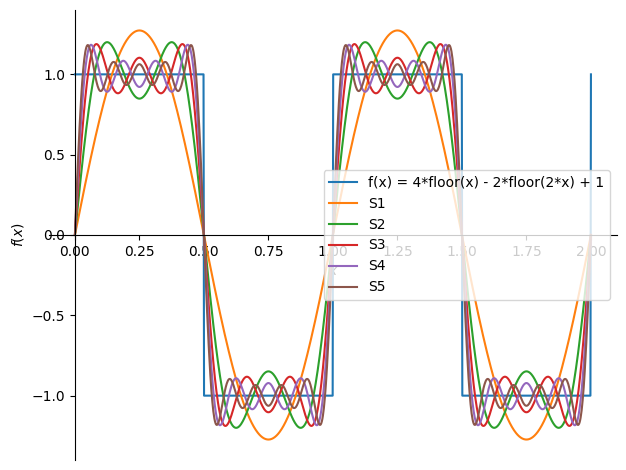

In [38]:
p = plot(
    (f, (x, 0, 2)),
    (S1, (x, 0, 2)),
    (S2, (x, 0, 2)),
    (S3, (x, 0, 2)),
    (S4, (x, 0, 2)),
    (S5, (x, 0, 2)),
    show=False,
    legend=True
)

p[0].label = "f(x) = 4*floor(x) - 2*floor(2*x) + 1"
p[1].label = "S1"
p[2].label = "S2"
p[3].label = "S3"
p[4].label = "S4"
p[5].label = "S5"

p.show()